# Stage 04: Predictive Modeling

Build and evaluate ML models to predict F1 race finishing positions. Compare baseline, regularized regression, tree-based, and ensemble approaches.

**Approach:**
- Temporal split: train on 2014–2022, test on 2023–2024 (no data leakage)
- GridSearchCV with 5-fold cross-validation for hyperparameter tuning
- Models: Baseline (grid position), Ridge, Lasso, Random Forest, XGBoost

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from src.models import (
    FEATURE_COLS, TARGET,
    temporal_train_test_split, BaselineModel,
    build_models, tune_and_evaluate, evaluate_model,
    save_model,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
SAVE_DIR = '../outputs/figures/'
MODEL_DIR = '../outputs/models/'

## 4.1 Prepare Training Data

In [2]:
features = pd.read_csv('../data/features/full_feature_matrix.csv')
print(f"Full dataset: {features.shape}")

X_train, X_test, y_train, y_test, train_df, test_df = temporal_train_test_split(features)

print(f"\nTrain: {X_train.shape[0]:,} rows (seasons {train_df['season'].min()}–{train_df['season'].max()})")
print(f"Test:  {X_test.shape[0]:,} rows (seasons {test_df['season'].min()}–{test_df['season'].max()})")
print(f"Features: {X_train.shape[1]}")
print(f"\nFeature list:")
for i, col in enumerate(FEATURE_COLS):
    print(f"  [{i}] {col}")

Full dataset: (4626, 31)

Train: 3,691 rows (seasons 2014–2022)
Test:  919 rows (seasons 2023–2024)
Features: 21

Feature list:
  [0] grid
  [1] qualifyingPosition
  [2] driver_rolling_position
  [3] driver_rolling_points
  [4] driver_consistency
  [5] driver_rolling_dnf_rate
  [6] driver_avg_position_gain
  [7] driver_career_races
  [8] driver_career_avg_position
  [9] driver_career_wins
  [10] driver_circuit_avg_position
  [11] team_rolling_points
  [12] team_rolling_position
  [13] team_rolling_best_position
  [14] team_reliability
  [15] team_development
  [16] track_position_std
  [17] track_avg_finish
  [18] track_dnf_rate
  [19] track_avg_position_gain
  [20] track_top3_conversion_rate


## 4.2 Baseline Model

Simple baseline: predict finishing position = starting grid position.

In [3]:
baseline = BaselineModel()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_metrics = evaluate_model(y_test, y_pred_baseline)
print("Baseline (grid position = finish position):")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.3f}")

Baseline (grid position = finish position):
  MAE: 3.362
  RMSE: 4.856
  R2: 0.290
  Median_AE: 2.000


## 4.3 Train All Models with Hyperparameter Tuning

GridSearchCV with 5-fold CV on the training set, then evaluate on the held-out 2023–2024 test set.

In [4]:
models_config = build_models()
results = {'Baseline': {'metrics': baseline_metrics, 'cv_mae': baseline_metrics['MAE'], 'best_params': {}}}
trained_models = {'Baseline': baseline}

for name, (model, param_grid) in models_config.items():
    print(f"\nTraining {name}...")
    best_model, cv_results, test_metrics = tune_and_evaluate(
        model, param_grid, X_train, y_train, X_test, y_test, cv=5
    )
    results[name] = {'metrics': test_metrics, **cv_results}
    trained_models[name] = best_model
    print(f"  Best params: {cv_results['best_params']}")
    print(f"  CV MAE: {cv_results['cv_mae']:.3f}")
    print(f"  Test MAE: {test_metrics['MAE']:.3f} | RMSE: {test_metrics['RMSE']:.3f} | R²: {test_metrics['R2']:.3f}")

print("\nAll models trained.")


Training Ridge...


  Best params: {'alpha': 100.0}
  CV MAE: 3.463
  Test MAE: 3.098 | RMSE: 4.012 | R²: 0.515

Training Lasso...
  Best params: {'alpha': 0.01}
  CV MAE: 3.463
  Test MAE: 3.099 | RMSE: 4.013 | R²: 0.515

Training RandomForest...


  Best params: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 200}
  CV MAE: 3.523
  Test MAE: 3.191 | RMSE: 4.103 | R²: 0.493

Training XGBoost...


  Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
  CV MAE: 3.498
  Test MAE: 3.306 | RMSE: 4.170 | R²: 0.476

All models trained.


## 4.4 Model Comparison

In [5]:
# Build comparison DataFrame
comparison = pd.DataFrame({
    name: {
        'CV MAE': r.get('cv_mae', r['metrics']['MAE']),
        'Test MAE': r['metrics']['MAE'],
        'Test RMSE': r['metrics']['RMSE'],
        'Test R²': r['metrics']['R2'],
        'Test Median AE': r['metrics']['Median_AE'],
    }
    for name, r in results.items()
}).T

comparison = comparison.sort_values('Test MAE')
print("Model Comparison (sorted by Test MAE):")
print(comparison.round(3).to_string())

best_model_name = comparison.index[0]
print(f"\nBest model: {best_model_name} (Test MAE: {comparison.iloc[0]['Test MAE']:.3f})")

Model Comparison (sorted by Test MAE):
              CV MAE  Test MAE  Test RMSE  Test R²  Test Median AE
Ridge          3.463     3.098      4.012    0.515           2.542
Lasso          3.463     3.099      4.013    0.515           2.524
RandomForest   3.523     3.191      4.103    0.493           2.628
XGBoost        3.498     3.306      4.170    0.476           2.830
Baseline       3.362     3.362      4.856    0.290           2.000

Best model: Ridge (Test MAE: 3.098)


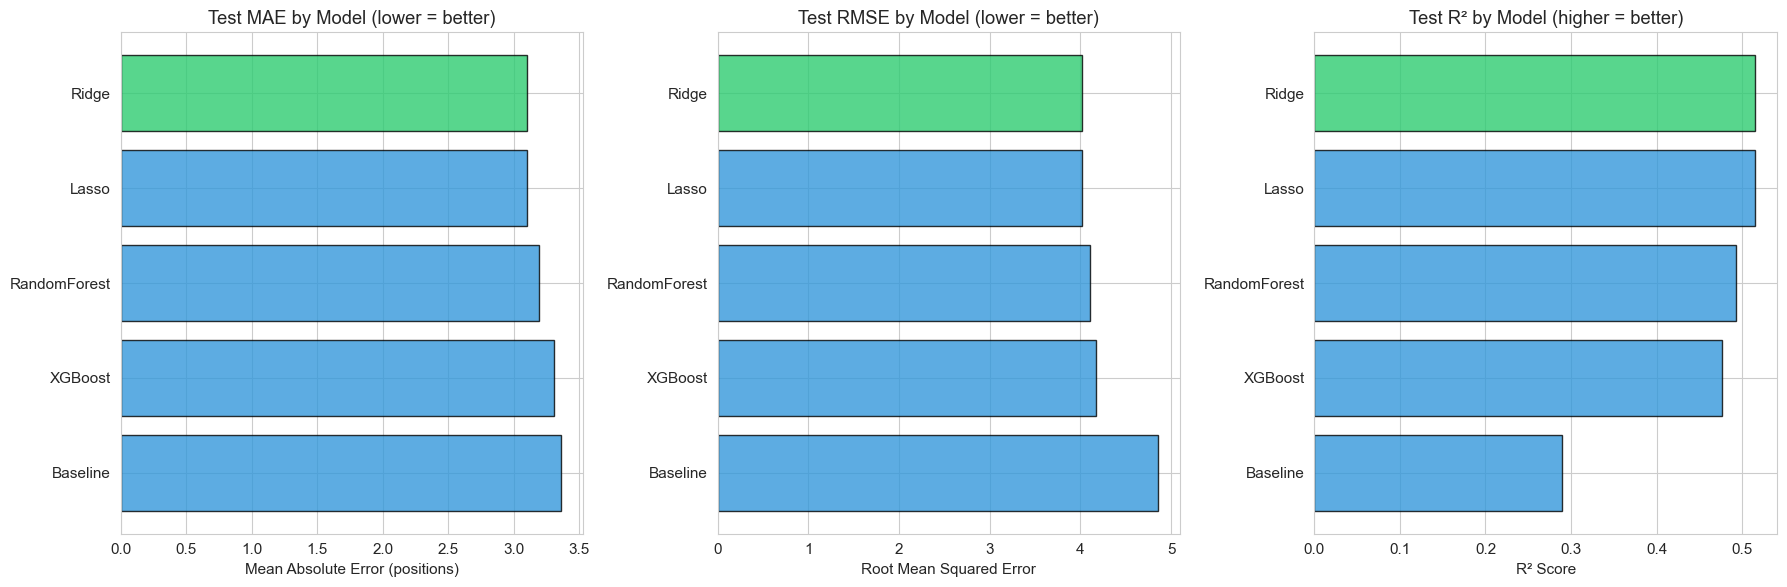

In [6]:
# Visualization: model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#2ecc71' if name == best_model_name else '#3498db' for name in comparison.index]

# MAE comparison
axes[0].barh(comparison.index, comparison['Test MAE'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Mean Absolute Error (positions)')
axes[0].set_title('Test MAE by Model (lower = better)')
axes[0].invert_yaxis()

# RMSE comparison
axes[1].barh(comparison.index, comparison['Test RMSE'], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Root Mean Squared Error')
axes[1].set_title('Test RMSE by Model (lower = better)')
axes[1].invert_yaxis()

# R² comparison
axes[2].barh(comparison.index, comparison['Test R²'], color=colors, edgecolor='black', alpha=0.8)
axes[2].set_xlabel('R² Score')
axes[2].set_title('Test R² by Model (higher = better)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Best Model: Predicted vs Actual

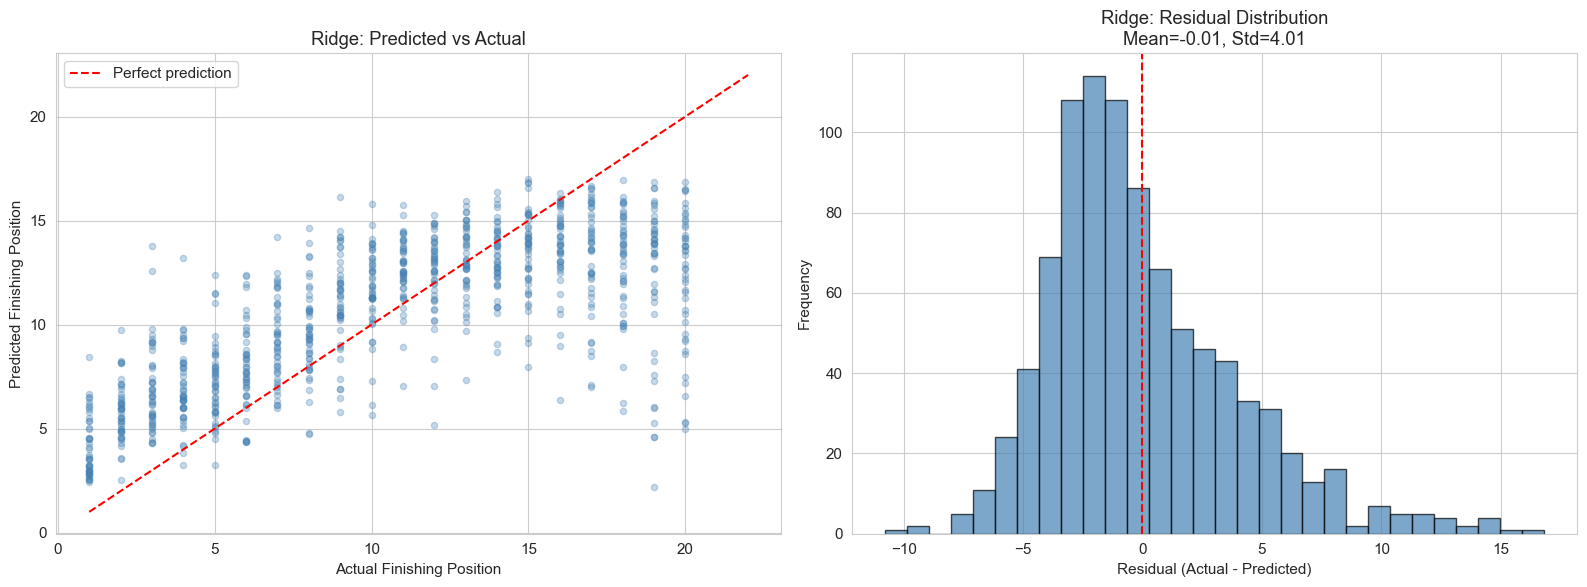


Ridge — Error by position group:
                mean  median  count
position_group                     
P1-3            3.62    3.43    138
P4-6            2.57    2.33    138
P7-10           2.37    2.10    184
P11-15          1.67    1.40    230
P16-22          5.11    4.54    229


In [7]:
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs actual scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=20, color='steelblue')
axes[0].plot([1, 22], [1, 22], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Finishing Position')
axes[0].set_ylabel('Predicted Finishing Position')
axes[0].set_title(f'{best_model_name}: Predicted vs Actual')
axes[0].legend()

# Residual distribution
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model_name}: Residual Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}best_model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Error by position range
test_analysis = test_df.copy()
test_analysis['predicted'] = y_pred_best
test_analysis['error'] = np.abs(test_analysis['position'] - test_analysis['predicted'])

bins = [0, 3, 6, 10, 15, 22]
labels = ['P1-3', 'P4-6', 'P7-10', 'P11-15', 'P16-22']
test_analysis['position_group'] = pd.cut(test_analysis['position'], bins=bins, labels=labels)

error_by_group = test_analysis.groupby('position_group', observed=True)['error'].agg(['mean', 'median', 'count'])
print(f"\n{best_model_name} — Error by position group:")
print(error_by_group.round(2).to_string())

## 4.6 Feature Importance

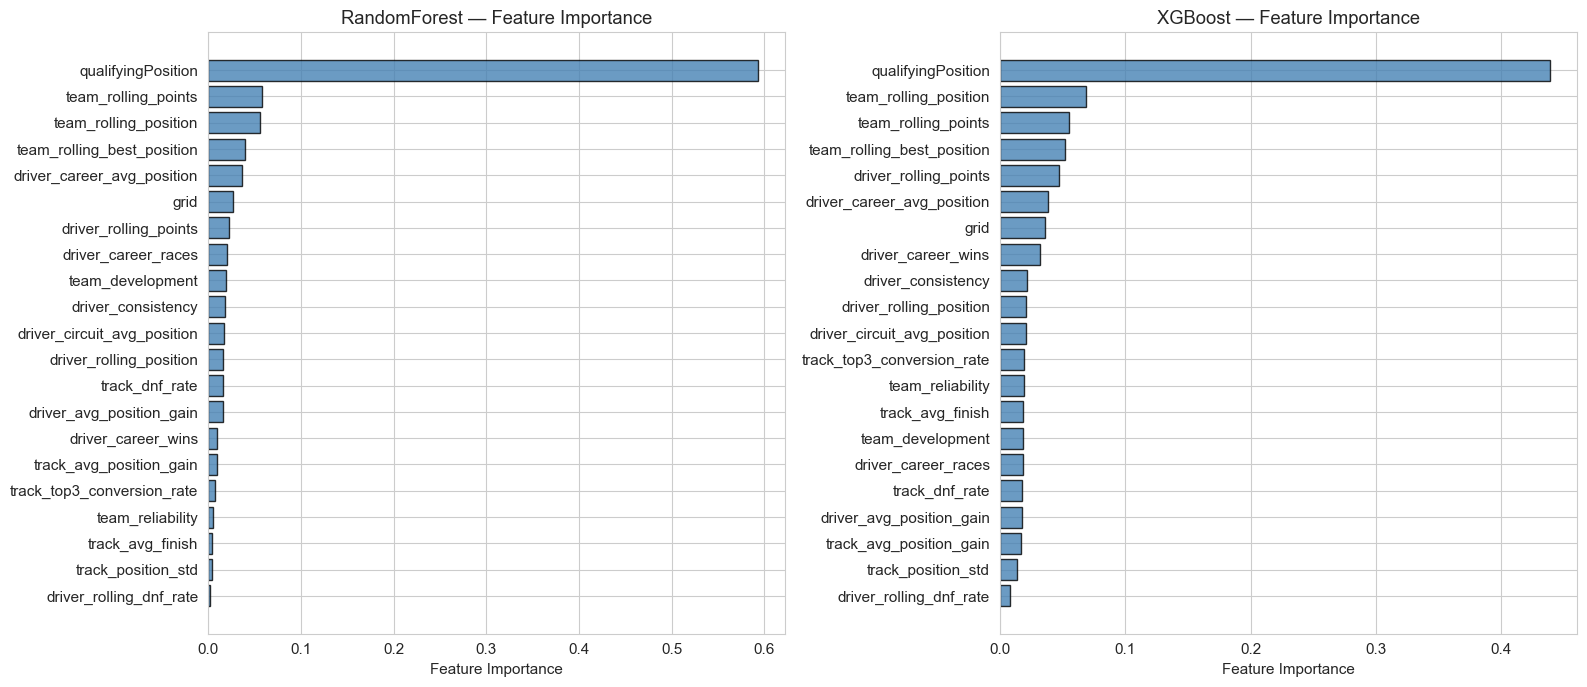

XGBoost — Top 10 Features:
  qualifyingPosition: 0.4385
  team_rolling_position: 0.0689
  team_rolling_points: 0.0554
  team_rolling_best_position: 0.0523
  driver_rolling_points: 0.0472
  driver_career_avg_position: 0.0381
  grid: 0.0360
  driver_career_wins: 0.0318
  driver_consistency: 0.0214
  driver_rolling_position: 0.0212


In [8]:
# Feature importance from tree-based models
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, name in zip(axes, ['RandomForest', 'XGBoost']):
    model = trained_models[name]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

    ax.barh(feat_imp.index, feat_imp.values, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{name} — Feature Importance')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features
xgb_imp = pd.Series(trained_models['XGBoost'].feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("XGBoost — Top 10 Features:")
for feat, imp in xgb_imp.head(10).items():
    print(f"  {feat}: {imp:.4f}")

## 4.7 Per-Season Performance

In [9]:
# How does the best model perform on 2023 vs 2024?
for season in [2023, 2024]:
    mask = test_df['season'] == season
    y_s = y_test[mask.values]
    y_p = y_pred_best[mask.values]
    m = evaluate_model(y_s, y_p)
    print(f"Season {season}: MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.3f} ({mask.sum()} entries)")

Season 2023: MAE=3.29, RMSE=4.27, R²=0.452 (440 entries)
Season 2024: MAE=2.92, RMSE=3.76, R²=0.573 (479 entries)


## 4.8 Save Best Model

In [10]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

# Save all trained models
for name, model in trained_models.items():
    if name == 'Baseline':
        continue
    path = f'{MODEL_DIR}{name.lower()}_model.pkl'
    save_model(model, path)
    print(f"Saved {name} to {path}")

# Save predictions for analysis
test_analysis[['season', 'round', 'driverId', 'driverCode', 'circuitId',
               'constructorName', 'grid', 'position', 'predicted', 'error']].to_csv(
    '../outputs/predictions/historical_predictions.csv', index=False
)
print(f"\nSaved historical predictions ({len(test_analysis)} rows)")

# Save comparison table
comparison.to_csv('../outputs/reports/model_comparison.csv')
print("Saved model comparison table")

Saved Ridge to ../outputs/models/ridge_model.pkl
Saved Lasso to ../outputs/models/lasso_model.pkl
Saved RandomForest to ../outputs/models/randomforest_model.pkl
Saved XGBoost to ../outputs/models/xgboost_model.pkl

Saved historical predictions (919 rows)
Saved model comparison table
